In [ ]:
!pip install mplsoccer

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplsoccer as ms
from mplsoccer import Sbopen
from collections import defaultdict, Counter
import random

loading games

In [ ]:
parser = Sbopen()

seasons = [106]
competition_id = 43

all_events = []

for season_id in seasons:
    df_matches = parser.match(competition_id = competition_id, season_id = season_id)

    for match_id in df_matches.match_id.unique():
        df_event = parser.event(match_id)[0]  # [0] = event dataframe
        df_event['match_id'] = match_id
        all_events.append(df_event)

df = pd.concat(all_events, ignore_index=True)

In [ ]:
group_stage_matches = df_matches[
    df_matches['competition_stage_name'] == 'Group Stage'
]['match_id'].tolist()

knockout_matches = df_matches[
    df_matches['competition_stage_name'] != 'Group Stage'
].copy()

In [ ]:
relevant_types = [
    'Pass', 'Carry', 'Shot', 'Dribble', 'Ball Receipt', 'Error',
    'Dispossessed', 'Miscontrol']

In [ ]:
df_main = df.loc[df['type_name'].isin(relevant_types)].copy()

In [ ]:
df_main = df_main[df_main['x'].notna() & df_main['y'].notna()]

In [ ]:
def get_zone(x, y):
    # pitch: 120 x 80

    # thirds (length)
    if x < 40:
        third = 'Def'
    elif x < 80:
        third = 'Mid'
    else:
        third = 'Final'

    # width split
    if y < 26.67:
        side = 'Left'
    elif y < 53.33:
        side = 'Center'
    else:
        side = 'Right'

    return f"{third}_{side}"

In [ ]:
STATES = [
    'Def_Left',   'Def_Center',   'Def_Right',
    'Mid_Left',   'Mid_Center',   'Mid_Right',
    'Final_Left', 'Final_Center', 'Final_Right',
    'Shot', 'Turnover'
]
TRANSIENT = STATES[:9]
ABSORBING = STATES[9:]

In [ ]:
def build_count_matrix(df_main, team_name, match_ids):
    """
    Counts all state transitions for a given team
    across the specified match_ids, using StatsBomb
    possession IDs to correctly bound each sequence.
    """
    counts = pd.DataFrame(0, index=STATES, columns=STATES)

    team_df = df_main[
        (df_main['team_name'] == team_name) &
        (df_main['match_id'].isin(match_ids))
    ].copy()

    for (match_id, poss_id), poss_events in team_df.groupby(['match_id', 'possession']):
        poss_events = poss_events.sort_values('index')
        rows = poss_events.to_dict('records')

        # transitions within the possession
        for i in range(len(rows) - 1):
            curr, nxt = rows[i], rows[i + 1]
            from_state = get_zone(curr['x'], curr['y'])

            if nxt['type_name'] == 'Shot':
                to_state = 'Shot'
            elif nxt['type_name'] in ['Dispossessed', 'Miscontrol', 'Error']:
                to_state = 'Turnover'
            else:
                to_state = get_zone(nxt['x'], nxt['y'])

            counts.loc[from_state, to_state] += 1

        # last event in the possession always terminates
        last = rows[-1]
        from_state = get_zone(last['x'], last['y'])
        if last['type_name'] == 'Shot':
            counts.loc[from_state, 'Shot'] += 1
        else:
            counts.loc[from_state, 'Turnover'] += 1

    return counts

In [ ]:
def counts_to_matrix(counts, smoothing=0.1):
    """
    Applies Laplace smoothing to transient rows only,
    then row-normalises. Absorbing states get identity rows.
    smoothing=0.1 is slightly generous to handle 3-game sparsity.
    """
    P = counts.copy().astype(float)
    P.loc[TRANSIENT] += smoothing
    P.loc[ABSORBING] = 0.0
    for s in ABSORBING:
        P.loc[s, s] = 1.0
    row_sums = P.loc[TRANSIENT].sum(axis=1)
    P.loc[TRANSIENT] = P.loc[TRANSIENT].div(row_sums, axis=0)
    return P

In [ ]:
group_stage_teams = pd.concat([
    df_matches[df_matches['match_id'].isin(group_stage_matches)][['home_team_name']].rename(columns={'home_team_name': 'team'}),
    df_matches[df_matches['match_id'].isin(group_stage_matches)][['away_team_name']].rename(columns={'away_team_name': 'team'})
])['team'].unique()

print(f"Teams found: {len(group_stage_teams)}")
print(sorted(group_stage_teams))

Teams found: 32
['Argentina', 'Australia', 'Belgium', 'Brazil', 'Cameroon', 'Canada', 'Costa Rica', 'Croatia', 'Denmark', 'Ecuador', 'England', 'France', 'Germany', 'Ghana', 'Iran', 'Japan', 'Mexico', 'Morocco', 'Netherlands', 'Poland', 'Portugal', 'Qatar', 'Saudi Arabia', 'Senegal', 'Serbia', 'South Korea', 'Spain', 'Switzerland', 'Tunisia', 'United States', 'Uruguay', 'Wales']


In [ ]:
team_group_matches = {}
for team in group_stage_teams:
    match_ids = df_matches[
        (df_matches['competition_stage_name'] == 'Group Stage') &
        ((df_matches['home_team_name'] == team) |
         (df_matches['away_team_name'] == team))
    ]['match_id'].tolist()
    team_group_matches[team] = match_ids

In [ ]:
team_matrices = {}
for team in group_stage_teams:
    counts = build_count_matrix(df_main, team, team_group_matches[team])
    team_matrices[team] = counts_to_matrix(counts, smoothing=0.1)

In [ ]:
# how likely a goal is from a shot taken from each position

ZONE_GOAL_PROB = {
    'Final_Center': 0.16,
    'Final_Left':   0.05,
    'Final_Right':  0.05,
    'Mid_Center':   0.03,
    'Mid_Left':     0.02,
    'Mid_Right':    0.02,
    'Def_Center':   0.015,
    'Def_Left':     0.008,
    'Def_Right':    0.008}

DEFAULT_GOAL_PROB = 0.025

In [ ]:
# POSSESSION SIMULATOR
# simulates a single possession sequence for one team.
# returns the absorbing state it ended in ('Shot' or 'Turnover')
# and the number of steps taken.

def simulate_possession(P_df, start_state=None):
    """
    Walks the Markov chain for one team until hitting an absorbing state.
    start_state: if None, samples from the stationary distribution of
                 transient states (weighted by how often each zone
                 starts a real possession).
    """
    if start_state is None:
        start_state = random.choice(TRANSIENT)

    state = start_state
    steps = 0

    while state not in ABSORBING:
        last_transient = state
        row = P_df.loc[state]
        state = random.choices(STATES, weights=row.values, k=1)[0]
        steps += 1

    return state, steps, last_transient

In [ ]:
# SINGLE GAME SIMULATOR
# alternates between two teams' chains. Each possession ends in either:
#   - shot → flip weighted coin → goal (score +1, reset) or no goal (other team kicks off)
#   - turnover → other team gets possession immediately
# clock is tracked in possession steps as a proxy for time.

def simulate_game(P_home, P_away, max_steps = 2000):
    """
    Simulates one full match between two teams.

    max_steps: proxy for 90 minutes. Calibrated after checking
               average steps per real game

    Returns: (home_goals, away_goals)
    """
    home_goals = 0
    away_goals = 0
    total_steps = 0

    # tracking possession counts for post-game stats
    home_possessions = 0
    away_possessions = 0
    home_shots = 0
    away_shots = 0
    home_shot_zones = []   # tracking where each shot came from to get goal probability
    away_shot_zones = []

    # coin flip for kickoff
    active = 'home' if random.random() < 0.5 else 'away'

    while total_steps < max_steps:
        P_active = P_home if active == 'home' else P_away

        outcome, steps, shot_zone = simulate_possession(P_active)
        total_steps += steps

        if active == 'home':
            home_possessions += 1
            if outcome == 'Shot':
                home_shots += 1
                home_shot_zones.append(shot_zone)
                goal_prob = ZONE_GOAL_PROB.get(shot_zone, DEFAULT_GOAL_PROB)
                if random.random() < goal_prob:
                    home_goals += 1
                active = 'away'      # keeper restarts play
            else:
                active = 'away'      # turnover
        else:
            away_possessions += 1
            if outcome == 'Shot':
                away_shots += 1
                away_shot_zones.append(shot_zone)
                goal_prob = ZONE_GOAL_PROB.get(shot_zone, DEFAULT_GOAL_PROB)
                if random.random() < goal_prob:
                    away_goals += 1
                active = 'home'
            else:
                active = 'home'

    return {
        'home_goals': home_goals,
        'away_goals': away_goals,
        'home_shots': home_shots,
        'away_shots': away_shots,
        'home_possessions': home_possessions,
        'away_possessions': away_possessions,
        'home_shot_zones': home_shot_zones,
        'away_shot_zones': away_shot_zones,
        'total_steps': total_steps
    }

at 2000 steps, the results are pretty sweet, around 25 shots with 3.2 goals on average for the best attacking teams in the tournament, and 20 shots with 2.7 goals for more defensive ones

In [ ]:
MAX_STEPS = 2000
N_SIMULATIONS = 1000

# MONTE CARLO MATCH SIMULATOR
# we simulate the same game 1000 times to get stable results

def simulate_match(P_home, P_away, n_sims=N_SIMULATIONS, max_steps = MAX_STEPS):
    """
    Runs n_sims full game simulations between two teams.
    Returns a summary dict with outcome distributions and
    averaged stats across all simulations.
    """
    results = []
    for _ in range(n_sims):
        results.append(simulate_game(P_home, P_away, max_steps=max_steps))

    # outcome counts
    home_wins = sum(r['home_goals'] > r['away_goals'] for r in results)
    away_wins = sum(r['home_goals'] < r['away_goals'] for r in results)
    draws     = sum(r['home_goals'] == r['away_goals'] for r in results)

    # scoreline distribution (top 10 most common)
    scorelines = Counter(
        (r['home_goals'], r['away_goals']) for r in results)

    # averaged stats
    avg_home_shots = np.mean([r['home_shots'] for r in results])
    avg_away_shots = np.mean([r['away_shots'] for r in results])
    avg_home_poss  = np.mean([r['home_possessions'] for r in results])
    avg_away_poss  = np.mean([r['away_possessions'] for r in results])

    # aggregate shot zone distributions across all simulations
    all_home_zones = [z for r in results for z in r['home_shot_zones']]
    all_away_zones = [z for r in results for z in r['away_shot_zones']]
    home_zone_dist = Counter(all_home_zones)
    away_zone_dist = Counter(all_away_zones)

    # effective xG per shot = weighted average conversion rate
    def effective_xg(zone_dist):
        total = sum(zone_dist.values())
        if total == 0:
            return 0
        return sum(ZONE_GOAL_PROB.get(z, DEFAULT_GOAL_PROB) * count
                   for z, count in zone_dist.items()) / total

    total = n_sims
    return {
        'home_win_pct':   round(home_wins / total * 100, 2),
        'draw_pct':       round(draws     / total * 100, 2),
        'away_win_pct':   round(away_wins / total * 100, 2),
        'avg_home_goals': round(np.mean([r['home_goals'] for r in results]), 2),
        'avg_away_goals': round(np.mean([r['away_goals'] for r in results]), 2),
        'avg_home_shots': round(avg_home_shots, 1),
        'avg_away_shots': round(avg_away_shots, 1),
        'home_poss_pct':  round(avg_home_poss / (avg_home_poss + avg_away_poss) * 100, 1),
        'away_poss_pct':  round(avg_away_poss / (avg_home_poss + avg_away_poss) * 100, 1),
        'home_eff_xg':    round(effective_xg(home_zone_dist), 3),
        'away_eff_xg':    round(effective_xg(away_zone_dist), 3),
        'home_zone_dist':  dict(home_zone_dist),
        'away_zone_dist':  dict(away_zone_dist),
        'scorelines':     scorelines.most_common(10),
        'raw':            results
        }

In [ ]:
def print_match_report(home_team, away_team, sim):
    print(f"\n{'='*52}")
    print(f"  {home_team}  vs  {away_team}")
    print(f"{'='*52}")
    print(f"  Outcome probabilities")
    print(f"    {home_team} win : {sim['home_win_pct']:>5.1f}%")
    print(f"    Draw           : {sim['draw_pct']:>5.1f}%")
    print(f"    {away_team} win : {sim['away_win_pct']:>5.1f}%")
    print(f"\n  Simulated averages per game")
    print(f"    Goals   : {sim['avg_home_goals']} – {sim['avg_away_goals']}")
    print(f"    Shots   : {sim['avg_home_shots']} – {sim['avg_away_shots']}")
    print(f"    Poss %  : {sim['home_poss_pct']}% – {sim['away_poss_pct']}%")
    print(f"    xG/shot : {sim['home_eff_xg']} – {sim['away_eff_xg']}")
    print(f"\n  Most common scorelines")
    for (hg, ag), count in sim['scorelines']:
        pct = count / N_SIMULATIONS * 100
        print(f"    {hg}–{ag}  ({pct:.1f}%)")
    print(f"{'='*52}")

In [ ]:
def get_winner(home_team, away_team, sim):
    if sim['home_win_pct'] > sim['away_win_pct']:
        return home_team
    elif sim['away_win_pct'] > sim['home_win_pct']:
        return away_team
    elif sim['avg_home_goals'] > sim['avg_away_goals']:
        return home_team
    elif sim['avg_away_goals'] > sim['avg_home_goals']:
        return away_team
    else:
        return random.choice([home_team, away_team])

In [198]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [199]:
# SIMULATING ALL R16 MATCHES

R16_BRACKET = [
    ('Netherlands',       'United States'),
    ('Argentina',         'Australia'),
    ('France',            'Poland'),
    ('England',           'Senegal'),
    ('Japan',             'Croatia'),
    ('Brazil',            'South Korea'),
    ('Morocco',           'Spain'),
    ('Portugal',          'Switzerland')]

r16_results = {}
for home, away in R16_BRACKET:
    sim = simulate_match(team_matrices[home], team_matrices[away])
    r16_results[(home, away)] = sim
    print_match_report(home, away, sim)


  Netherlands  vs  United States
  Outcome probabilities
    Netherlands win :  40.9%
    Draw           :  26.8%
    United States win :  32.3%

  Simulated averages per game
    Goals   : 1.55 – 1.4
    Shots   : 10.3 – 11.5
    Poss %  : 50.0% – 50.0%
    xG/shot : 0.146 – 0.119

  Most common scorelines
    1–1  (11.5%)
    2–1  (8.6%)
    1–0  (7.9%)
    1–2  (7.3%)
    2–0  (7.2%)
    0–0  (6.8%)
    0–1  (6.7%)
    2–2  (6.2%)
    3–1  (4.7%)
    1–3  (4.3%)

  Argentina  vs  Australia
  Outcome probabilities
    Argentina win :  56.1%
    Draw           :  21.4%
    Australia win :  22.5%

  Simulated averages per game
    Goals   : 2.12 – 1.35
    Shots   : 16.1 – 10.0
    Poss %  : 50.1% – 49.9%
    xG/shot : 0.13 – 0.139

  Most common scorelines
    2–1  (10.6%)
    1–1  (9.5%)
    1–0  (7.7%)
    3–1  (6.6%)
    2–2  (6.2%)
    1–2  (5.9%)
    2–0  (5.8%)
    3–0  (5.2%)
    3–2  (4.4%)
    0–1  (3.4%)

  France  vs  Poland
  Outcome probabilities
    France win :  69.2%


In [200]:
r16_winners = []
for (home, away), sim in r16_results.items():
    winner = get_winner(home, away, sim)
    print(f"{home} vs {away}  →  predicted: {winner}")
    r16_winners.append(winner)

Netherlands vs United States  →  predicted: Netherlands
Argentina vs Australia  →  predicted: Argentina
France vs Poland  →  predicted: France
England vs Senegal  →  predicted: England
Japan vs Croatia  →  predicted: Croatia
Brazil vs South Korea  →  predicted: Brazil
Morocco vs Spain  →  predicted: Spain
Portugal vs Switzerland  →  predicted: Switzerland


In [201]:
# SIMULATING QUARTERFINAL MATCHES

qf_pairs = list(zip(r16_winners[::2], r16_winners[1::2]))

qf_results = {}
for home, away in qf_pairs:
    sim = simulate_match(team_matrices[home], team_matrices[away])
    qf_results[(home, away)] = sim
    print_match_report(home, away, sim)


  Netherlands  vs  Argentina
  Outcome probabilities
    Netherlands win :  26.2%
    Draw           :  25.5%
    Argentina win :  48.3%

  Simulated averages per game
    Goals   : 1.2 – 1.68
    Shots   : 8.5 – 13.0
    Poss %  : 50.0% – 50.0%
    xG/shot : 0.146 – 0.129

  Most common scorelines
    1–1  (12.9%)
    0–1  (10.1%)
    1–2  (8.1%)
    0–2  (6.6%)
    1–0  (6.5%)
    2–1  (6.2%)
    1–3  (6.1%)
    0–0  (5.5%)
    2–2  (5.1%)
    0–3  (4.9%)

  France  vs  England
  Outcome probabilities
    France win :  42.6%
    Draw           :  19.6%
    England win :  37.8%

  Simulated averages per game
    Goals   : 1.94 – 1.77
    Shots   : 14.2 – 13.4
    Poss %  : 50.0% – 50.0%
    xG/shot : 0.133 – 0.13

  Most common scorelines
    2–1  (8.9%)
    1–2  (8.2%)
    1–1  (7.2%)
    2–0  (6.1%)
    2–2  (5.4%)
    0–2  (4.9%)
    1–3  (4.9%)
    3–1  (4.6%)
    0–1  (4.5%)
    1–0  (3.9%)

  Croatia  vs  Brazil
  Outcome probabilities
    Croatia win :  27.0%
    Draw         

In [202]:
qf_winners = []
for (home, away), sim in qf_results.items():
    winner = get_winner(home, away, sim)
    print(f"{home} vs {away}  →  predicted: {winner}")
    qf_winners.append(winner)

Netherlands vs Argentina  →  predicted: Argentina
France vs England  →  predicted: France
Croatia vs Brazil  →  predicted: Brazil
Spain vs Switzerland  →  predicted: Spain


In [203]:
# SIMULATING SEMIFINAL MATCHES

sf_pairs = [
    (qf_winners[0], qf_winners[2]),
    (qf_winners[1], qf_winners[3]),
]

sf_results = {}
for home, away in sf_pairs:
    sim = simulate_match(team_matrices[home], team_matrices[away])
    sf_results[(home, away)] = sim
    print_match_report(home, away, sim)


  Argentina  vs  Brazil
  Outcome probabilities
    Argentina win :  33.5%
    Draw           :  24.0%
    Brazil win :  42.5%

  Simulated averages per game
    Goals   : 1.7 – 1.89
    Shots   : 13.6 – 15.0
    Poss %  : 50.0% – 50.0%
    xG/shot : 0.128 – 0.129

  Most common scorelines
    1–1  (11.4%)
    1–2  (8.1%)
    1–3  (6.7%)
    2–2  (6.7%)
    2–1  (6.0%)
    0–1  (5.0%)
    2–0  (4.8%)
    1–0  (4.5%)
    0–2  (4.2%)
    3–1  (4.0%)

  France  vs  Spain
  Outcome probabilities
    France win :  48.3%
    Draw           :  24.6%
    Spain win :  27.1%

  Simulated averages per game
    Goals   : 1.7 – 1.21
    Shots   : 12.5 – 9.8
    Poss %  : 50.0% – 50.0%
    xG/shot : 0.134 – 0.127

  Most common scorelines
    1–1  (11.3%)
    2–1  (9.2%)
    1–0  (9.1%)
    1–2  (8.1%)
    2–0  (7.8%)
    2–2  (6.6%)
    3–1  (6.0%)
    0–0  (5.9%)
    0–1  (5.2%)
    0–2  (4.5%)


In [204]:
sf_winners = []
for (home, away), sim in sf_results.items():
    winner = get_winner(home, away, sim)
    print(f"{home} vs {away}  →  predicted: {winner}")
    sf_winners.append(winner)

Argentina vs Brazil  →  predicted: Brazil
France vs Spain  →  predicted: France


In [205]:
# SIMULATING THE FINAL MATCH

final_home, final_away = sf_winners[0], sf_winners[1]
final_sim = simulate_match(team_matrices[final_home], team_matrices[final_away])
print_match_report(final_home, final_away, final_sim)
champion = get_winner(final_home, final_away, final_sim)


  Brazil  vs  France
  Outcome probabilities
    Brazil win :  37.3%
    Draw           :  19.4%
    France win :  43.3%

  Simulated averages per game
    Goals   : 2.1 – 2.26
    Shots   : 15.9 – 16.4
    Poss %  : 50.0% – 50.0%
    xG/shot : 0.129 – 0.134

  Most common scorelines
    1–2  (8.3%)
    2–2  (6.7%)
    1–3  (6.1%)
    2–3  (5.9%)
    1–1  (5.6%)
    2–1  (5.6%)
    3–2  (5.3%)
    3–1  (5.2%)
    3–3  (4.1%)
    1–0  (3.7%)


Evaluation

In [206]:
ACTUAL_RESULTS = {
    ('Netherlands',  'United States'): 'Netherlands',
    ('Argentina',    'Australia'):     'Argentina',
    ('France',       'Poland'):        'France',
    ('England',      'Senegal'):       'England',
    ('Japan',        'Croatia'):       'Croatia',
    ('Brazil',       'South Korea'):   'Brazil',
    ('Morocco',      'Spain'):         'Morocco',
    ('Portugal',     'Switzerland'):   'Portugal',
    ('Netherlands',  'Argentina'):     'Argentina',
    ('France',       'England'):       'France',
    ('Croatia',      'Brazil'):        'Croatia',
    ('Morocco',      'Portugal'):      'Morocco',
    ('Argentina',    'Croatia'):       'Argentina',
    ('France',       'Morocco'):       'France',
    ('Argentina',    'France'):        'Argentina'}

all_results = {**r16_results, **qf_results, **sf_results,
               (final_home, final_away): final_sim}

correct, total = 0, 0
rows = []
for (home, away), sim in all_results.items():
    predicted = get_winner(home, away, sim)
    actual    = ACTUAL_RESULTS.get((home, away)) or ACTUAL_RESULTS.get((away, home))
    if actual:
        is_correct = predicted == actual
        correct   += is_correct
        total     += 1
        rows.append({
            'stage':     'R16'   if (home, away) in r16_results else
                         'QF'    if (home, away) in qf_results  else
                         'SF'    if (home, away) in sf_results  else 'Final',
            'match':          f"{home} vs {away}",
            'predicted':       predicted,
            'actual':          actual,
            'correct':         '✓' if is_correct else '✗',
            'home_win_pct':    sim['home_win_pct'],
            'away_win_pct':    sim['away_win_pct'],
        })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f"\nOverall accuracy: {correct}/{total}  ({correct/total*100:.1f}%)")
print(f"Predicted champion: {champion}")

stage                        match   predicted      actual correct  home_win_pct  away_win_pct
  R16 Netherlands vs United States Netherlands Netherlands       ✓          40.9          32.3
  R16       Argentina vs Australia   Argentina   Argentina       ✓          56.1          22.5
  R16             France vs Poland      France      France       ✓          69.2          14.2
  R16           England vs Senegal     England     England       ✓          42.3          37.1
  R16             Japan vs Croatia     Croatia     Croatia       ✓          36.9          41.6
  R16        Brazil vs South Korea      Brazil      Brazil       ✓          47.9          32.3
  R16             Morocco vs Spain       Spain     Morocco       ✗          32.6          42.3
  R16      Portugal vs Switzerland Switzerland    Portugal       ✗          37.6          38.1
   QF     Netherlands vs Argentina   Argentina   Argentina       ✓          26.2          48.3
   QF            France vs England      France    

visualisations

In [207]:
# everything the visualisations need, computed once up front.

def get_team_metrics(P_df):
    Q = P_df.loc[TRANSIENT, TRANSIENT].values.astype(float)
    R = P_df.loc[TRANSIENT, ABSORBING].values.astype(float)
    N = np.linalg.inv(np.eye(9) - Q)
    B = pd.DataFrame(N @ R, index=TRANSIENT, columns=ABSORBING)
    return {
        'shot_absorption':     round(B['Shot'].mean(), 4),
        'turnover_absorption': round(B['Turnover'].mean(), 4),
        'final_third_shot':    round(B.loc[['Final_Left',
                                            'Final_Center',
                                            'Final_Right'], 'Shot'].mean(), 4),
    }

team_metrics = {
    team: get_team_metrics(P)
    for team, P in team_matrices.items()
}

# converting to dataframe for easy plotting
metrics_df = pd.DataFrame(team_metrics).T.reset_index()
metrics_df.columns = ['team', 'shot_absorption',
                      'turnover_absorption', 'final_third_shot']
metrics_df = metrics_df.sort_values('shot_absorption', ascending=False).reset_index(drop=True)
metrics_df['rank'] = metrics_df.index + 1

print(metrics_df[['rank', 'team', 'shot_absorption']].to_string(index=False))

 rank          team  shot_absorption
    1       Germany           0.2364
    2        France           0.2061
    3        Brazil           0.2003
    4       England           0.1918
    5       Senegal           0.1906
    6     Argentina           0.1811
    7       Belgium           0.1775
    8   South Korea           0.1754
    9      Portugal           0.1699
   10         Spain           0.1623
   11        Serbia           0.1538
   12      Cameroon           0.1512
   13        Mexico           0.1499
   14         Japan           0.1476
   15          Iran           0.1451
   16       Uruguay           0.1439
   17        Canada           0.1411
   18  Saudi Arabia           0.1405
   19       Denmark           0.1379
   20       Morocco           0.1356
   21       Tunisia           0.1352
   22 United States           0.1350
   23       Croatia           0.1346
   24   Switzerland           0.1278
   25       Ecuador           0.1253
   26         Ghana           0.1212
 

In [208]:
import plotly.express as px
import plotly.graph_objects as go

knockout_teams = [
    'Netherlands', 'United States', 'Argentina', 'Australia',
    'France', 'Poland', 'England', 'Senegal',
    'Japan', 'Croatia', 'Brazil', 'South Korea',
    'Morocco', 'Spain', 'Portugal', 'Switzerland'
]

metrics_df['status'] = metrics_df['team'].apply(
    lambda t: 'Knockout Stage' if t in knockout_teams else 'Group Stage Exit'
)

fig = px.bar(
    metrics_df.sort_values('shot_absorption', ascending=True),
    x='shot_absorption',
    y='team',
    color='status',
    orientation='h',
    color_discrete_map={
        'Knockout Stage':   'lightgreen',
        'Group Stage Exit': '#6b7280'
    },
    text=metrics_df.sort_values('shot_absorption', ascending=True)['shot_absorption'].apply(lambda x: f'{x:.4f}'),
    title='Team Power Ranking — Shot Absorption Probability<br><sup>Derived purely from group stage Markov chain transition matrices</sup>',
    labels={'shot_absorption': 'Shot Absorption Probability', 'team': ''},
    template='plotly_dark',
    height=850,
)

fig.update_traces(textposition='outside', textfont=dict(size=9))

fig.update_layout(
    title=dict(x=0.5, xanchor='center', font=dict(size=16)),
    xaxis=dict(
        title='Shot Absorption Probability',
        range=[0, metrics_df['shot_absorption'].max() + 0.03],
        gridcolor='#1f2937',
    ),
    yaxis=dict(tickfont=dict(size=10)),
    legend=dict(
        title=dict(text='Tournament Stage'),
        x=0.72, y=0.05,
        bgcolor='rgba(255,255,255,0.05)',
        bordercolor='#374151',
        borderwidth=1,
    ),
    margin=dict(l=10, r=120, t=80, b=50),
    hovermode='y unified',
)

fig.show()

In [209]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from collections import Counter

ACTUAL_SCORELINES = {
    ('Netherlands',  'United States'): (3, 1),
    ('Argentina',    'Australia'):     (2, 1),
    ('France',       'Poland'):        (3, 1),
    ('England',      'Senegal'):       (3, 0),
    ('Japan',        'Croatia'):       (1, 1),
    ('Brazil',       'South Korea'):   (4, 1),
    ('Morocco',      'Spain'):         (0, 0),
    ('Portugal',     'Switzerland'):   (6, 1)
}

CORRECT = {
    ('Netherlands',  'United States'): True,
    ('Argentina',    'Australia'):     True,
    ('France',       'Poland'):        True,
    ('England',      'Senegal'):       True,
    ('Japan',        'Croatia'):       True,
    ('Brazil',       'South Korea'):   True,
    ('Morocco',      'Spain'):         False,
    ('Portugal',     'Switzerland'):   False
}

TOP_N = 18   # number of scorelines to show per subplot

fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[f"{h} vs {a}" for h, a in R16_BRACKET],
    vertical_spacing=0.1,
    horizontal_spacing=0.08
)

for idx, (home, away) in enumerate(R16_BRACKET):
    row = idx // 2 + 1
    col = idx %  2 + 1

    sim     = r16_results[(home, away)]
    raw     = sim['raw']
    actual  = ACTUAL_SCORELINES[(home, away)]
    correct = CORRECT[(home, away)]

    # scoreline frequency distribution
    all_scorelines = Counter((r['home_goals'], r['away_goals']) for r in raw)
    total_sims     = len(raw)

    # order by frequency, take top N
    top_scorelines = all_scorelines.most_common(TOP_N)
    labels  = [f"{hg}-{ag}" for (hg, ag), _ in top_scorelines]
    counts  = [c for _, c in top_scorelines]
    pcts    = [c / total_sims * 100 for c in counts]

    # find actual scoreline position in this top-N list
    actual_label = f"{actual[0]}-{actual[1]}"
    actual_rank_in_full = sorted(all_scorelines.keys(),
                                 key=lambda s: -all_scorelines[s])
    actual_full_rank    = next((i for i, s in enumerate(actual_rank_in_full)
                                if s == actual), None)

    # percentile: what fraction of simulations had a MORE common scoreline
    sims_more_common = sum(c for s, c in all_scorelines.items()
                           if all_scorelines[s] > all_scorelines.get(actual, 0))
    percentile = round(sims_more_common / total_sims * 100, 1)

    # bar colours — highlighting actual if in top N
    bar_colours = []
    for (hg, ag), _ in top_scorelines:
        if (hg, ag) == actual:
            bar_colours.append('#fbbf24')   # gold = actual scoreline
        else:
            bar_colours.append('#4c9be8' if correct else '#e8734c')

    # adding bars
    fig.add_trace(
        go.Bar(
            x=labels,
            y=pcts,
            marker=dict(color=bar_colours, line=dict(width=0)),
            hovertemplate='%{x}: %{y:.1f}%<extra></extra>',
            showlegend=False,
        ),
        row=row, col=col)

    # if actual scoreline is NOT in top N, annotation on the right
    actual_in_top = actual_label in labels
    if not actual_in_top:
        actual_pct = all_scorelines.get(actual, 0) / total_sims * 100
        fig.add_annotation(
            row=row, col=col,
            x=TOP_N - 1,    # far right of the x axis
            y=max(pcts) * 0.85,
            text=f'Actual: {actual_label}<br>{actual_pct:.1f}% ({percentile}th pct)',
            showarrow=True,
            arrowhead=2,
            arrowcolor='#fbbf24',
            font=dict(color='#fbbf24', size=9),
            bgcolor='rgba(0,0,0,0.5)',
            bordercolor='#fbbf24',
            borderwidth=1,
            ax=40, ay=-30)
    else:
        # annotating the gold bar directly
        actual_x_pos = labels.index(actual_label)
        fig.add_annotation(
            row=row, col=col,
            x=actual_label,
            y=pcts[actual_x_pos] + max(pcts) * 0.08,
            text=f'Actual<br>{percentile}th pct',
            showarrow=False,
            font=dict(color='#fbbf24', size=8))

# subplot title colours (green = correct, red = wrong)
for i, (home, away) in enumerate(R16_BRACKET):
    colour = '#22c55e' if CORRECT[(home, away)] else '#ef4444'
    fig.layout.annotations[i].font.color  = colour
    fig.layout.annotations[i].font.size   = 11

fig.update_layout(
    template='plotly_dark',
    title=dict(
        text='Simulated Scoreline Distribution vs Actual Result — R16<br>'
             '<sup>Gold bar = actual scoreline · '
             'Percentile = % of simulations that predicted a more likely scoreline · '
             'Green title = correct winner · Red = incorrect</sup>',
        font=dict(size=15),
        x=0.5, xanchor='center'),
    height=1400,
    margin=dict(t=120, b=50, l=50, r=50),
    bargap=0.15)

fig.update_yaxes(title_text='% of simulations', title_font=dict(size=9),
                 gridcolor='#1f2937')
fig.update_xaxes(tickfont=dict(size=8), tickangle=45)

fig.show()

In [210]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
from scipy.stats import gaussian_kde

ACTUAL_SCORELINES = {
    ('Netherlands',  'United States'): (3, 1),
    ('Argentina',    'Australia'):     (2, 1),
    ('France',       'Poland'):        (3, 1),
    ('England',      'Senegal'):       (3, 0),
    ('Japan',        'Croatia'):       (1, 1),
    ('Brazil',       'South Korea'):   (4, 1),
    ('Morocco',      'Spain'):         (0, 0),
    ('Portugal',     'Switzerland'):   (6, 1),
}

CORRECT = {
    ('Netherlands',  'United States'): True,
    ('Argentina',    'Australia'):     True,
    ('France',       'Poland'):        True,
    ('England',      'Senegal'):       True,
    ('Japan',        'Croatia'):       True,
    ('Brazil',       'South Korea'):   True,
    ('Morocco',      'Spain'):         False,
    ('Portugal',     'Switzerland'):   False,
}

fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[f"{h} vs {a}" for h, a in R16_BRACKET],
    vertical_spacing=0.10,
    horizontal_spacing=0.10
)

for idx, (home, away) in enumerate(R16_BRACKET):
    row = idx // 2 + 1
    col = idx %  2 + 1

    sim    = r16_results[(home, away)]
    raw    = sim['raw']
    actual = ACTUAL_SCORELINES[(home, away)]
    actual_gd = actual[0] - actual[1]

    # goal difference across all simulations
    goal_diffs = np.array([r['home_goals'] - r['away_goals'] for r in raw])

    # KDE over a smooth x range
    kde       = gaussian_kde(goal_diffs, bw_method=0.4)
    x_range   = np.linspace(goal_diffs.min() - 1, goal_diffs.max() + 1, 300)
    kde_vals  = kde(x_range)

    # percentile: fraction of simulations with smaller absolute GD
    # i.e. how extreme was the actual result
    actual_density  = kde(actual_gd)[0]
    peak_density    = kde_vals.max()
    # how far into the tail: % of x_range with higher density than actual point
    pct_more_likely = round(np.mean(kde_vals > actual_density) * 100, 1)

    correct     = CORRECT[(home, away)]
    curve_col   = '#4c9be8' if correct else '#e8734c'
    fill_col    = 'rgba(76, 155, 232, 0.15)' if correct else 'rgba(232, 115, 76, 0.15)'

    # KDE curve
    fig.add_trace(
        go.Scatter(
            x=x_range,
            y=kde_vals,
            mode='lines',
            line=dict(color=curve_col, width=2),
            fill='tozeroy',
            fillcolor=fill_col,
            hovertemplate='GD: %{x:.1f}<extra></extra>',
            showlegend=False),
        row=row, col=col)

    # vertical line at actual goal difference
    fig.add_vline(
        x=actual_gd,
        line=dict(color='#fbbf24', width=2, dash='dash'),
        row=row, col=col)

    # peak of distribution (modal prediction)
    modal_gd = x_range[np.argmax(kde_vals)]

    # annotations: modal GD and actual GD
    fig.add_annotation(
        row=row, col=col,
        x=modal_gd,
        y=peak_density * 1.08,
        text=f'Modal: {modal_gd:+.1f}',
        showarrow=False,
        font=dict(color=curve_col, size=9),
        xanchor='center')

    fig.add_annotation(
        row=row, col=col,
        x=actual_gd,
        y=peak_density * 0.6,
        text=f'Actual: {actual_gd:+d}<br>{pct_more_likely}th pctl',
        showarrow=False,
        font=dict(color='#fbbf24', size=9),
        bgcolor='rgba(0,0,0,0.5)',
        bordercolor='#fbbf24',
        borderwidth=1,
        xanchor='left' if actual_gd <= modal_gd else 'right')

    # zero reference line
    fig.add_vline(
        x=0,
        line=dict(color='#6b7280', width=1, dash='dot'),
        row=row, col=col)

# subplot title colours
for i, (home, away) in enumerate(R16_BRACKET):
    colour = '#22c55e' if CORRECT[(home, away)] else '#ef4444'
    fig.layout.annotations[i].font.color = colour
    fig.layout.annotations[i].font.size  = 11

fig.update_layout(
    template='plotly_dark',
    title=dict(
        text='Simulated Goal Difference Distribution vs Actual Result — R16<br>'
             '<sup>Dashed gold line = actual goal difference · '
             'Green title = correct winner predicted · Red = incorrect<br>'
             'Low percentile → actual result sits near the peak → model predicted this well · '
             'High percentile → actual result sits in the tail → model was surprised</sup>',
        font=dict(size=15),
        x=0.5, xanchor='center'),
    height=1400,
    margin=dict(t=140, b=50, l=50, r=50))  # increased top margin for longer title

fig.update_xaxes(
    title_text='Goal Difference (Home − Away)',
    title_font=dict(size=9),
    tickfont=dict(size=8),
    gridcolor='#1f2937',
    zerolinecolor='#374151')
fig.update_yaxes(
    title_text='Density',
    title_font=dict(size=9),
    gridcolor='#1f2937',
    showticklabels=False)

fig.show()

In [211]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

semi_finalists = ['Argentina', 'France', 'Croatia', 'Morocco']

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=semi_finalists,
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

for idx, team in enumerate(semi_finalists):
    row = idx // 2 + 1
    col = idx %  2 + 1

    P    = team_matrices[team]
    Q    = P.loc[TRANSIENT, TRANSIENT].values.astype(float)
    Q_df = pd.DataFrame(Q, index=TRANSIENT, columns=TRANSIENT)

    # ── readable axis labels
    short = {
        'Def_Left':    'DL', 'Def_Center':   'DC', 'Def_Right':   'DR',
        'Mid_Left':    'ML', 'Mid_Center':   'MC', 'Mid_Right':   'MR',
        'Final_Left':  'FL', 'Final_Center': 'FC', 'Final_Right': 'FR',
    }
    labels = [short[s] for s in TRANSIENT]

    # ── hover text: full state names + probability
    hover_text = []
    for i, from_s in enumerate(TRANSIENT):
        row_text = []
        for j, to_s in enumerate(TRANSIENT):
            row_text.append(
                f'<b>{from_s} → {to_s}</b><br>'
                f'Probability: {Q[i, j]:.3f}'
            )
        hover_text.append(row_text)

    # ── cell annotations (probability values)
    annotations_text = [
        [f'{Q[i, j]:.2f}' if Q[i, j] >= 0.03 else ''
         for j in range(9)]
        for i in range(9)
    ]

    fig.add_trace(
        go.Heatmap(
            z=Q,
            x=labels,
            y=labels,
            text=annotations_text,
            texttemplate='%{text}',
            textfont=dict(size=8),
            hovertext=hover_text,
            hovertemplate='%{hovertext}<extra></extra>',
            colorscale=[
                [0.0,  '#0d1117'],
                [0.2,  '#1e3a5f'],
                [0.5,  '#2d6a9f'],
                [0.8,  '#4c9be8'],
                [1.0,  '#93c5fd'],
            ],
            zmin=0,
            zmax=0.5,
            showscale=(idx == 0),   # only one colourbar
            colorbar=dict(
                title=dict(
                    text='Transition<br>Probability',
                    font=dict(color='#9ca3af', size=10)
                ),
                tickfont=dict(color='#9ca3af', size=9),
                thickness=12,
                len=0.45,
                y=0.78,
            ),
        ),
        row=row, col=col
    )

    # ── diagonal highlight — self-loops (ball stays in same zone)
    for i in range(9):
        fig.add_shape(
            type='rect',
            x0=i - 0.5, x1=i + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color='#fbbf24', width=1.5),
            fillcolor='rgba(0,0,0,0)',
            row=row, col=col
        )

# ── subplot title colours by team
title_colours = {
    'Argentina': '#4c9be8',
    'France':    '#e8734c',
    'Croatia':   '#22c55e',
    'Morocco':   '#fbbf24',
}
for i, team in enumerate(semi_finalists):
    fig.layout.annotations[i].font.color = title_colours[team]
    fig.layout.annotations[i].font.size  = 13

fig.update_layout(
    template='plotly_dark',
    title=dict(
        text='Possession Transition Matrices — 2022 WC Semi-Finalists<br>'
             '<sup>9×9 transient block · rows = from state · cols = to state · '
             'values = transition probability · '
             'gold border = self-loop (possession retained in same zone) · '
             'DL/DC/DR = Defensive · ML/MC/MR = Middle · FL/FC/FR = Final third</sup>',
        font=dict(size=15),
        x=0.5, xanchor='center'
    ),
    height=850,
    width=950,
    margin=dict(t=130, b=60, l=60, r=60),
)

fig.update_xaxes(
    tickfont=dict(size=10),
    showgrid=False,
    title_font=dict(color='#9ca3af', size=9),
)
fig.update_yaxes(
    tickfont=dict(size=10),
    showgrid=False,
    autorange='reversed',
    title_font=dict(color='#9ca3af', size=9),
)

fig.show()

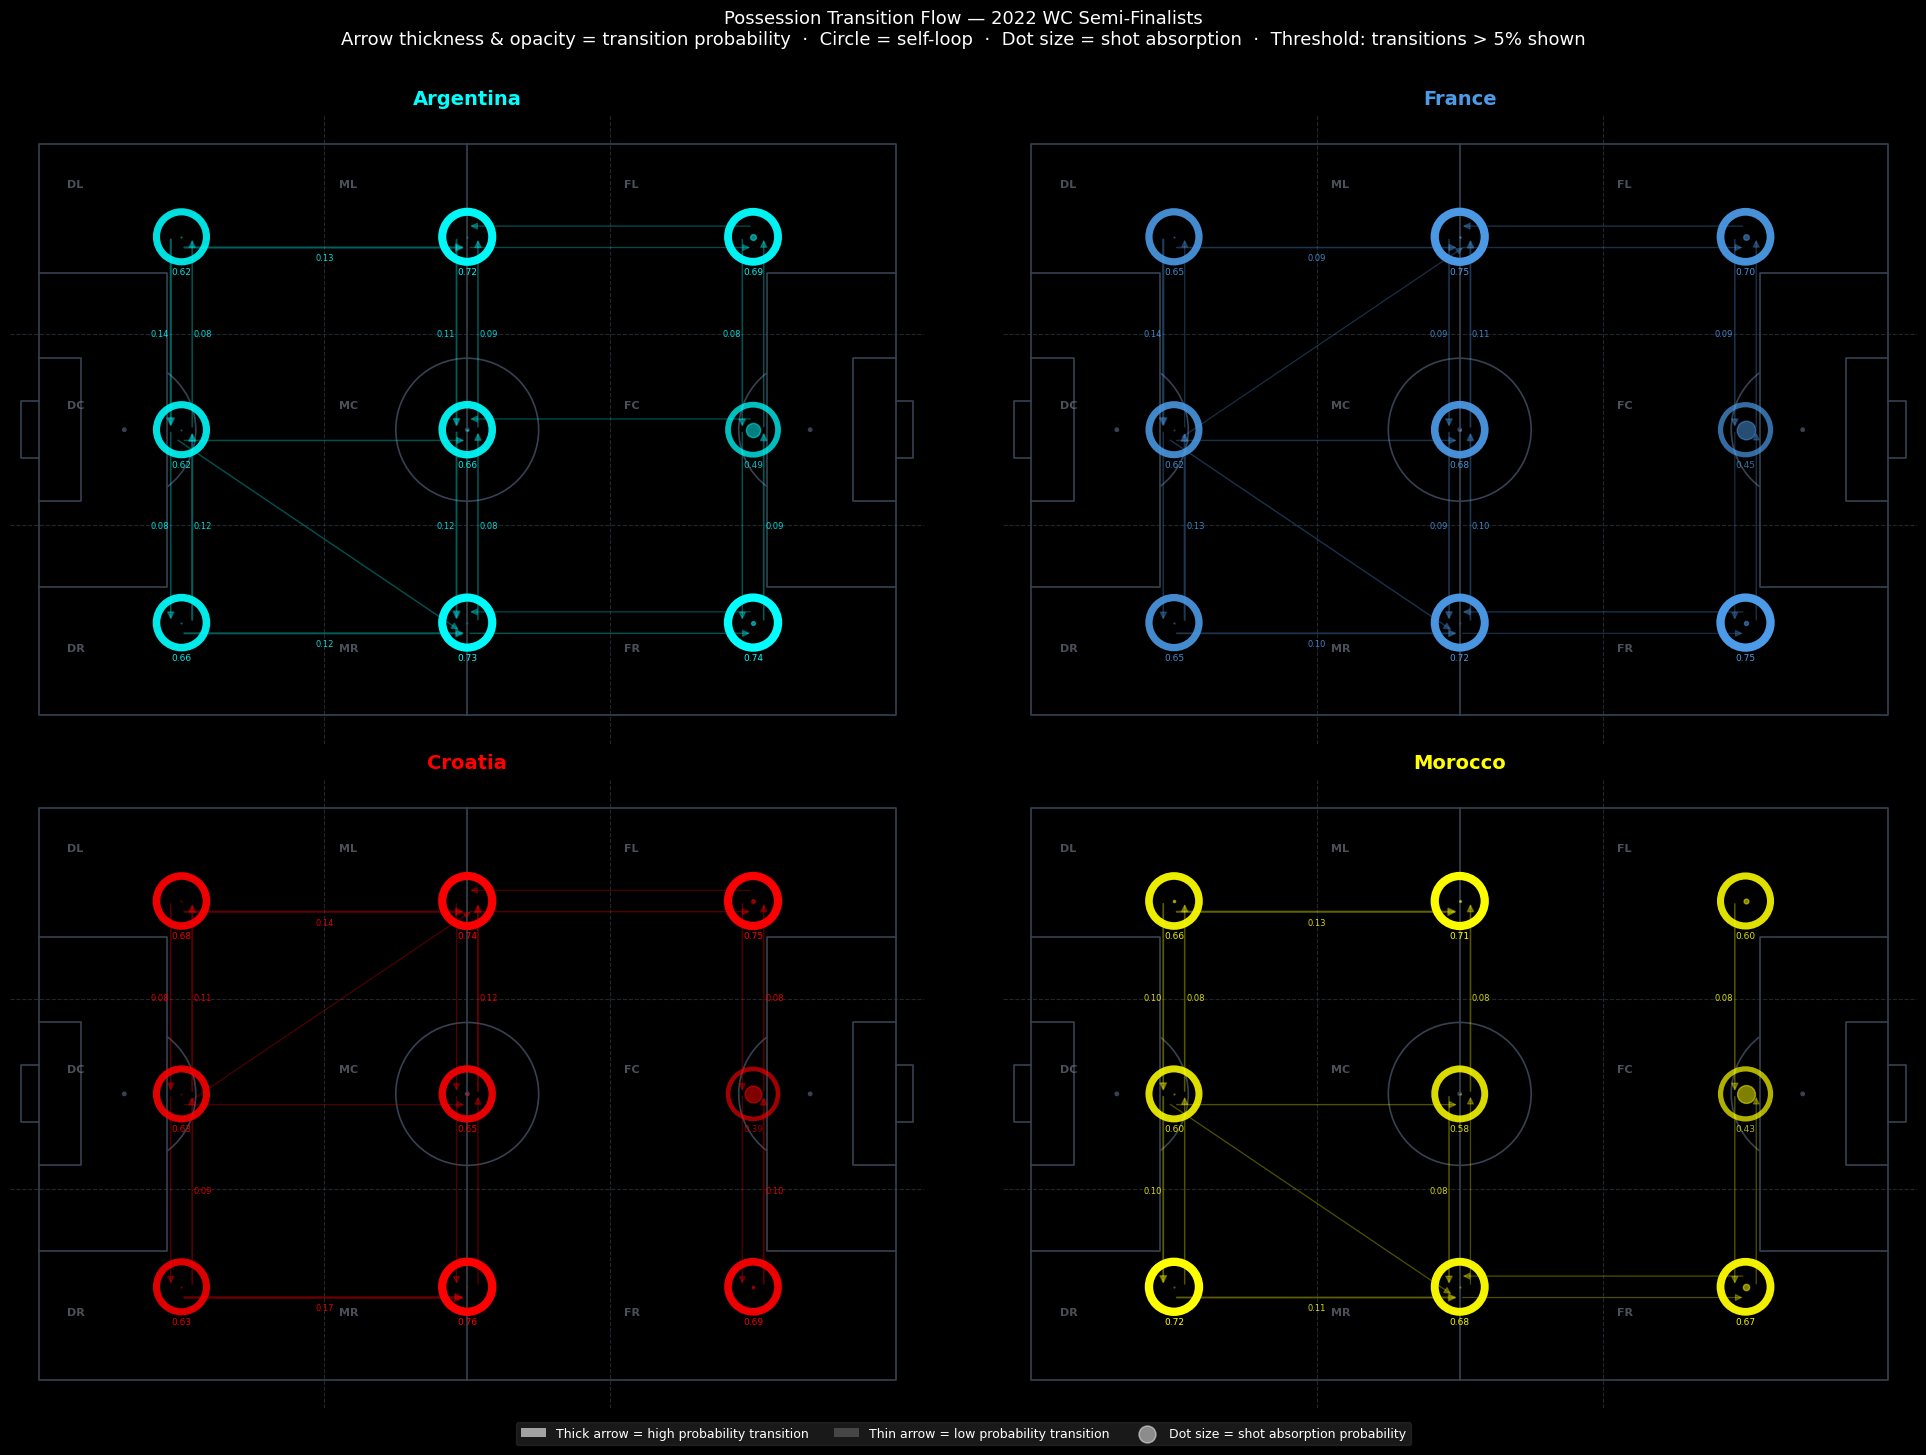

In [212]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np
from mplsoccer import Pitch

# ZONE CENTROIDS (120x80 pitch)
ZONE_CENTROIDS = {
    'Def_Left':    (20, 13),
    'Def_Center':  (20, 40),
    'Def_Right':   (20, 67),
    'Mid_Left':    (60, 13),
    'Mid_Center':  (60, 40),
    'Mid_Right':   (60, 67),
    'Final_Left':  (100, 13),
    'Final_Center':(100, 40),
    'Final_Right': (100, 67),
}

semi_finalists  = ['Argentina', 'France', 'Croatia', 'Morocco']
team_colours    = {
    'Argentina': 'cyan',
    'France':    '#4c9be8',
    'Croatia':   'red',
    'Morocco':   'yellow',
}

# threshold: only drawing arrows above this probability to avoid clutter
ARROW_THRESHOLD = 0.05

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor('black')

for idx, team in enumerate(semi_finalists):
    ax  = axes[idx // 2][idx % 2]
    col = team_colours[team]

    # drawing pitch
    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color='black',
        line_color='#374151',
        linewidth=1.2,
        goal_type='box',
    )
    pitch.draw(ax=ax)

    # drawing zone boundaries
    for x_line in [40, 80]:
        ax.axvline(x_line, color='#374151', linewidth=0.8,
                   linestyle='--', alpha=0.6)
    for y_line in [26.67, 53.33]:
        ax.axhline(y_line, color='#374151', linewidth=0.8,
                   linestyle='--', alpha=0.6)

    # zone labels
    zone_labels = {
        'Def_Left':    (4,  6),   'Def_Center':  (4,  37),  'Def_Right':   (4,  71),
        'Mid_Left':    (42, 6),   'Mid_Center':  (42, 37),  'Mid_Right':   (42, 71),
        'Final_Left':  (82, 6),   'Final_Center':(82, 37),  'Final_Right': (82, 71),
    }
    short = {
        'Def_Left': 'DL', 'Def_Center': 'DC', 'Def_Right': 'DR',
        'Mid_Left': 'ML', 'Mid_Center': 'MC', 'Mid_Right': 'MR',
        'Final_Left': 'FL', 'Final_Center': 'FC', 'Final_Right': 'FR',
    }
    for state, (lx, ly) in zone_labels.items():
        ax.text(lx, ly, short[state], color='#6b7280',
                fontsize=8, fontweight='bold', alpha=0.7)

    # transition matrix
    P = team_matrices[team]
    Q = P.loc[TRANSIENT, TRANSIENT]

    # arrows
    max_prob = Q.values.max()

    for from_state in TRANSIENT:
        for to_state in TRANSIENT:
            prob = Q.loc[from_state, to_state]
            if prob < ARROW_THRESHOLD:
                continue

            x1, y1 = ZONE_CENTROIDS[from_state]
            x2, y2 = ZONE_CENTROIDS[to_state]

            # normalising thickness and alpha
            norm_prob  = prob / max_prob
            linewidth  = 0.5 + norm_prob * 5.5
            alpha      = 0.25 + norm_prob * 0.75

            if from_state == to_state:
                # self-loop: drawing a small circle at the centroid
                circle = plt.Circle(
                    (x1, y1), radius=3.5,
                    color=col, fill=False,
                    linewidth=linewidth, alpha=alpha
                )
                ax.add_patch(circle)
                ax.text(x1, y1 + 5.5, f'{prob:.2f}',
                        color=col, fontsize=6.5,
                        ha='center', va='bottom', alpha=alpha)
            else:
                # offsetting arrows slightly so A→B and B→A don't overlap
                dx, dy  = x2 - x1, y2 - y1
                length  = np.hypot(dx, dy)
                perp_x  = -dy / length * 1.5
                perp_y  =  dx / length * 1.5

                ax.annotate(
                    '',
                    xy=(x2 + perp_x, y2 + perp_y),
                    xytext=(x1 + perp_x, y1 + perp_y),
                    arrowprops=dict(
                        arrowstyle='-|>',
                        color=col,
                        lw=linewidth,
                        alpha=alpha,
                        mutation_scale=10 + norm_prob * 8,
                    )
                )
                # probability label at arrow midpoint
                mid_x = (x1 + x2) / 2 + perp_x * 2
                mid_y = (y1 + y2) / 2 + perp_y * 2
                if prob >= 0.08:   # only label significant arrows
                    ax.text(mid_x, mid_y, f'{prob:.2f}',
                            color=col, fontsize=6,
                            ha='center', va='center', alpha=0.85)

    # shot and turnover absorption indicators at zone centroids
    for state in TRANSIENT:
        shot_prob = P.loc[state, 'Shot']
        turn_prob = P.loc[state, 'Turnover']
        cx, cy    = ZONE_CENTROIDS[state]

        # small dot sized by shot absorption
        ax.scatter(cx, cy, s=shot_prob * 800,
                   color=col, alpha=0.5, zorder=5)

    # title
    ax.set_title(team, color=col, fontsize=14,
                 fontweight='bold', pad=8)

# global title and legend
fig.suptitle(
    'Possession Transition Flow — 2022 WC Semi-Finalists\n'
    'Arrow thickness & opacity = transition probability  ·  '
    'Circle = self-loop  ·  Dot size = shot absorption  ·  '
    'Threshold: transitions > 5% shown',
    color='white', fontsize=13, y=1.01)

# shared legend
legend_elements = [
    mpatches.Patch(facecolor='white', alpha=0.6,
                   label='Thick arrow = high probability transition'),
    mpatches.Patch(facecolor='white', alpha=0.2,
                   label='Thin arrow = low probability transition'),
    plt.scatter([], [], s=150, color='white', alpha=0.5,
                label='Dot size = shot absorption probability')]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, framealpha=0.1,
           labelcolor='white', fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('transition_flow_pitch.png', dpi=250,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()